<a href="https://colab.research.google.com/github/josevin720/dados_de_norne/blob/main/C%C3%B3pia_de_Aula_perfilagem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/josevin720/dados_de_norne.git

Cloning into 'dados_de_norne'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 22 (delta 10), reused 22 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 6.21 MiB | 7.17 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [2]:
!pip install lasio
import pandas as pd # Serve para trabalhar com dataframes
import lasio # Serve para importar arquivos .las
import matplotlib.pyplot as plt # Visualização dos dados em forma de curvas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.5 MB/s eta 0:00:00


In [5]:
well = lasio.read("dados_de_norne/660810-B-4H.las").df().reset_index(drop=False)

In [6]:
def despike(curve, window_size, tolerance):
  import numpy as np
  smoothed = []
  despiked = []
  for i in range(0, len(curve) - window_size + 1):
    mean = np.average(curve[i:i+window_size])
    smoothed.append(mean)
  for j in range(len(curve)-window_size+2, len(curve)+1):
    mean = sum(curve[-window_size:])/window_size
    smoothed.append(mean)
  for k in range(0, len(curve)):
    if abs(smoothed[k]-curve[k])>=tolerance:
      despiked.append(smoothed[k])
    else:
      despiked.append(curve[k])
  return despiked

Caso o arquivo esteja em .csv, usar o comando:

`well = pd.read_csv("/content/density_nn_norne/660810-D-4H.csv")`


Equações de argilosidade

Idade terciária ou mais nova:

$V_{sh} = 0.083(2^{3.7*IGR}-1)$

Pré-terciária ou mais antiga:

$V_{sh} = 0.33(2^{2*IGR}-1)$

$IGR = \frac{GR-GR_{min}}{GR_{max}-GR_{min}} $



In [7]:
igr = (well.GR - well.GR.min()) / (well.GR.max() - well.GR.min())

In [8]:
vsh = 0.083*(2**(3.7*igr)-1)

In [9]:
def vsh(gr_log):
  igr = (gr_log - gr_log.min()) / (gr_log.max() - gr_log.min())
  # vsh = 0.083*(2**(3.7*igr)-1) # Idade terciária ou mais nova
  vsh = 0.33*(2**(2*igr)-1) # Pré-terciária ou mais antiga
  return vsh

vsh = vsh(well.GR)
# vsh1 = vsh(well1.GR)
# vsh2 = vsh(well2.GR)
# ...

In [10]:
well.columns

Index(['DEPTH', 'TVD', 'TVDSS', 'DT', 'DTS', 'GR', 'KLOGH', 'NPHI', 'PHIF',
       'RHOB', 'SW', 'VSH'],
      dtype='object')

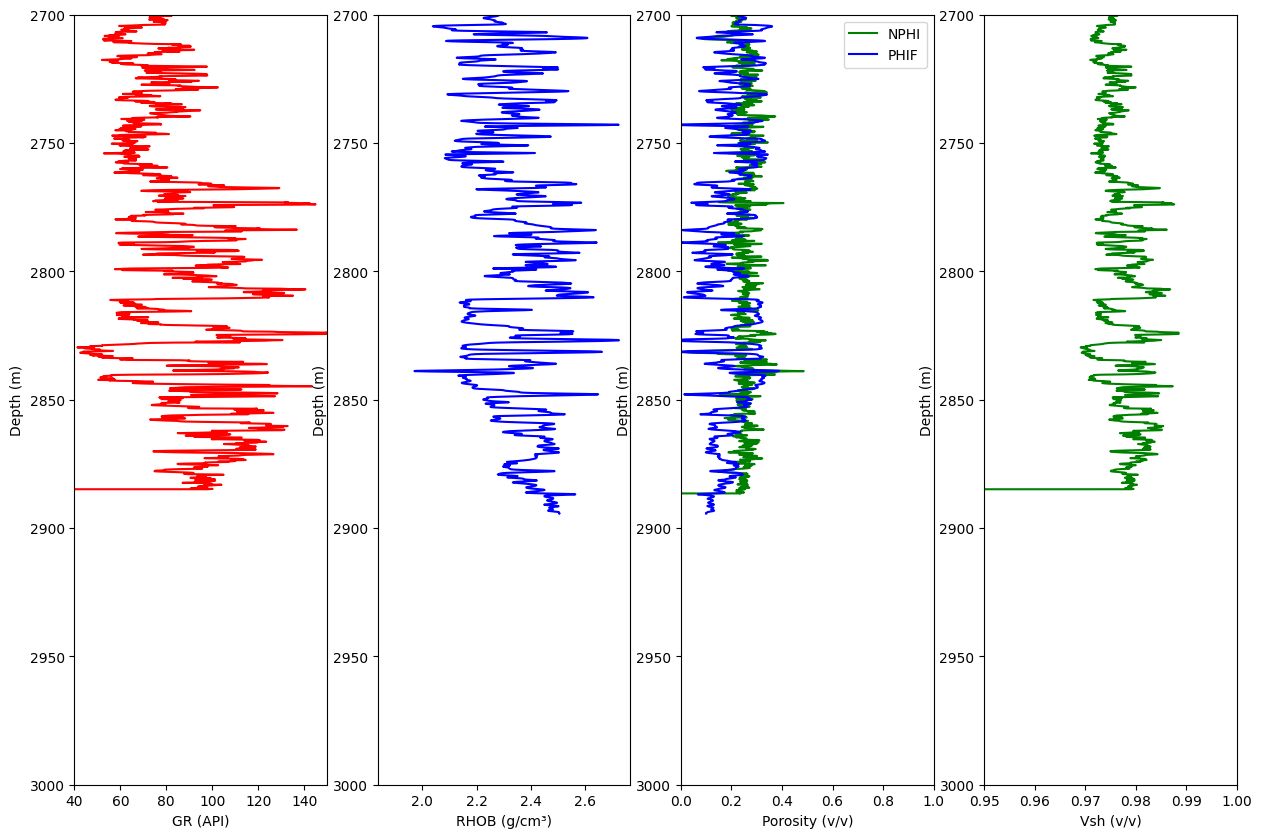

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(15, 10))

y_lim = [2700, 3000]

# lines = [3000] # ADICIONAR AO CÓDIGO

ax[0].plot(well.GR, well.DEPTH, c='red')
# for i in lines: # ADICIONAR AO CÓDIGO
#   ax[0].axhline(y=i, color='r', linestyle='-')
ax[0].set_xlabel('GR (API)')
ax[0].set_ylabel('Depth (m)')
ax[0].set_ylim(y_lim)
ax[0].set_xlim(40, 150)
ax[0].invert_yaxis()

ax[1].plot(well.RHOB, well.DEPTH, c='blue')
ax[1].set_xlabel('RHOB (g/cm³)')
ax[1].set_ylabel('Depth (m)')
ax[1].set_ylim(y_lim)
ax[1].invert_yaxis()

ax[2].plot(well.NPHI, well.DEPTH, c='green', label='NPHI')
ax[2].plot(well.PHIF, well.DEPTH, c='blue', label='PHIF')
ax[2].legend()
ax[2].set_xlabel('Porosity (v/v)')
ax[2].set_ylabel('Depth (m)')
ax[2].set_xlim(0, 1)
ax[2].set_ylim(y_lim)
ax[2].invert_yaxis()

ax[3].plot(vsh, well.DEPTH, c='green')
ax[3].set_xlabel('Vsh (v/v)')
ax[3].set_ylabel('Depth (m)')
ax[3].set_xlim(0.95, 1)
ax[3].set_ylim(y_lim)
ax[3].invert_yaxis()
